In [91]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, fbeta_score
from scipy.stats import randint, uniform

In [92]:
TRAIN_PATH = "./train.csv"
VALIDATION_PATH = "./validation.csv"
TEST_PATH = "./test.csv"

In [93]:
SSM_PATH = "./ssm_final_features_new_data_new_label.csv"

In [94]:
tca_train_df= pd.read_csv(TRAIN_PATH)
tca_validation_df= pd.read_csv(VALIDATION_PATH)
tca_test_df= pd.read_csv(TEST_PATH)

In [95]:
j1=pd.merge(tca_train_df, tca_test_df, on=["conv_id","turn_id"], how='inner')
j2=pd.merge(tca_train_df, tca_validation_df, on=["conv_id","turn_id"], how='inner')
j3=pd.merge(tca_validation_df, tca_test_df, on=["conv_id","turn_id"], how='inner')

assert len(j1) == 0
assert len(j2) == 0
assert len(j3) == 0

In [96]:
ssm_df = pd.read_csv(SSM_PATH)

In [97]:
train_df = pd.merge(tca_train_df, ssm_df, on=["conv_id","turn_id"], how='inner')
validation_df = pd.merge(tca_validation_df, ssm_df, on=["conv_id","turn_id"], how='inner')
test_df = pd.merge(tca_test_df, ssm_df, on=["conv_id","turn_id"], how='inner')

In [98]:
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {validation_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (8668, 1563)
Validation shape: (2844, 1563)
Test shape: (2872, 1563)


In [99]:
train_df

,origin_drift,drift_momentum,persistent_drift_count,std_similarity,max_similarity,prev_progressive,interaction_risk_ema3,pattern_risk_ema3,toxicity_diff,threat_diff,...,1532,1533,1534,1535,y,long_term_state_drift_sqrt,mean_squared_change_long_sqrt,state_input_distance_sqrt,long_term_state_similarity_sqrt,state_similarity_log
0,-1.342565,-1.0,-0.630930,-0.557276,-3.282211,-0.343347,-0.221530,-0.982146,-0.007846,-0.023199,...,-0.052584,-0.005000,-0.038129,-0.020168,0,1.000000,1.000000,1.444391,1.414214,9.999995e-07
1,-0.005320,-1.0,0.000000,-0.557276,-0.447156,-0.337271,-0.250529,-0.233093,-0.004262,-0.000299,...,0.007467,0.024220,0.001111,0.016277,0,1.139617,1.000059,1.452137,1.337711,5.819199e-01
2,0.638550,0.0,0.369070,0.306272,-0.447156,-0.003498,-0.273522,0.102516,-0.005107,-0.022322,...,-0.025632,-0.022314,0.015822,0.000744,0,1.166689,1.000085,1.450848,1.296392,6.365507e-01
3,0.906540,0.0,0.630930,0.606330,-0.240826,0.339797,-0.283230,0.373226,-0.007235,-0.023197,...,-0.014585,-0.005549,0.004717,-0.005025,0,1.161274,1.000080,1.444922,1.296767,6.549771e-01
4,0.836720,0.0,0.834044,0.486223,-0.240826,0.752221,-0.282138,0.766055,0.000398,-0.023199,...,-0.069477,0.020833,-0.010719,-0.002960,0,1.169809,1.000089,1.440488,1.287193,6.495546e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8663,-1.342565,-1.0,-0.630930,-0.557276,-3.282211,-0.343347,0.806596,-0.982146,-0.007846,-0.023199,...,-0.038625,-0.000941,0.032386,0.012283,0,1.000000,1.000000,1.443241,1.414214,9.999995e-07
8664,-0.078354,-1.0,0.000000,-0.557276,-0.362044,-0.242917,0.341142,-0.275426,11.869164,4.431023,...,-0.005284,-0.023395,0.013047,-0.044293,0,1.204283,1.000133,1.477583,1.314080,5.462731e-01
8665,0.335435,0.0,0.369070,0.138877,-0.139474,0.076999,0.569035,0.167690,-0.006426,11.336238,...,-0.044960,0.002316,0.016324,0.001410,0,1.198982,1.000125,1.478756,1.322379,6.514034e-01
8666,0.199199,0.0,0.630930,0.205144,0.038915,0.565353,0.306026,0.177857,0.097184,8.075825,...,-0.001872,0.003716,0.028786,-0.010973,0,1.303539,1.000319,1.521941,1.270258,6.382231e-01


In [100]:
assert train_df.shape[0] == tca_train_df.shape[0], "Train data merge failed"
assert validation_df.shape[0] == tca_validation_df.shape[0], "Validation data merge failed"
assert test_df.shape[0] == tca_test_df.shape[0], "Test data merge failed"

In [101]:
vector_list= list(str(col) for col in range(768+768))
train_vectors = train_df[vector_list].values
validation_vectors = validation_df[vector_list].values
test_vectors = test_df[vector_list].values

In [102]:
train_df.drop(columns=vector_list, inplace=True)
validation_df.drop(columns=vector_list, inplace=True)
test_df.drop(columns=vector_list, inplace=True)

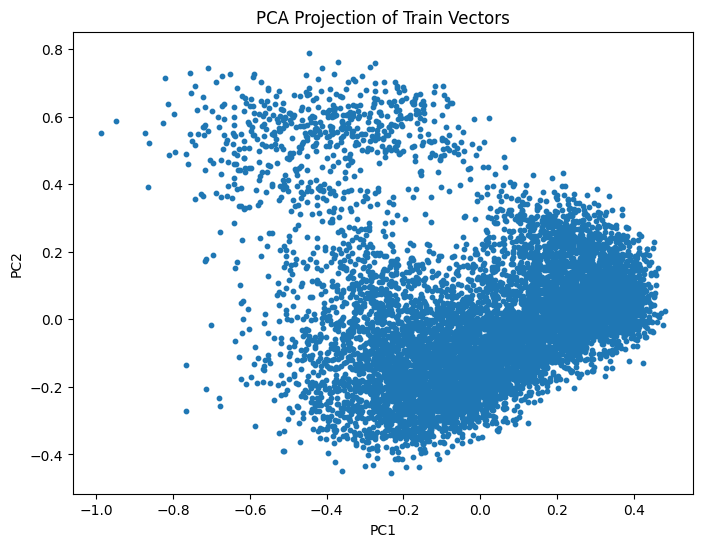

In [103]:
pca = PCA(n_components=2)   
reduced = pca.fit_transform(train_vectors)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:, 0], reduced[:, 1], s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Train Vectors")
plt.show()

In [105]:
pca = PCA()
pca.fit(train_vectors)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

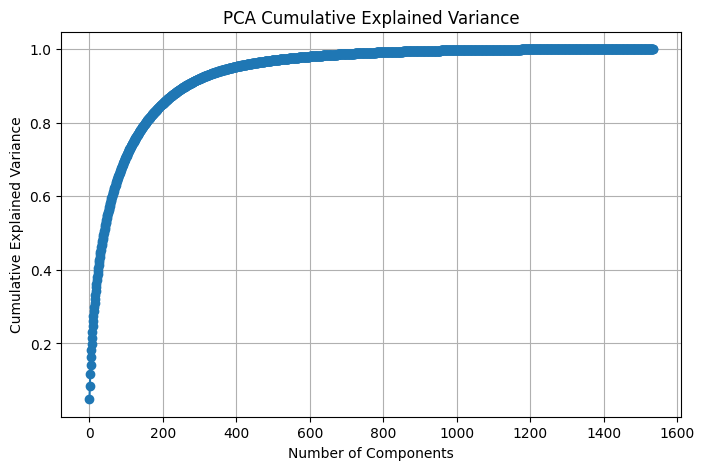

In [106]:
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [107]:
pca = PCA(n_components=0.95)  
train_pca = pca.fit_transform(train_vectors)

print("Original dims:", train_vectors.shape[1])
print("Reduced dims:", train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original dims: 1536
Reduced dims: 390
Explained variance: 0.9502382131194088


In [ ]:
# joblib.dump(pca, "./models/pca_model_new_labels.pkl")

['./models/pca_model_new_labels.pkl']

In [108]:
train_vectors = train_pca
validation_vectors = pca.transform(validation_vectors)
test_vectors = pca.transform(test_vectors)

In [109]:
pca_columns = [f"{i}" for i in range(train_vectors.shape[1])]

train_pca_df = pd.DataFrame(train_vectors,columns=pca_columns,index=train_df.index)
validation_pca_df = pd.DataFrame(validation_vectors,columns=pca_columns,index=validation_df.index)
test_pca_df = pd.DataFrame(test_vectors,columns=pca_columns,index=test_df.index)


train_df = pd.concat([train_df, train_pca_df], axis=1)
validation_df = pd.concat([validation_df, validation_pca_df], axis=1)
test_df = pd.concat([test_df, test_pca_df], axis=1)

In [110]:
X_train = train_df.drop(columns=["label", "y"])
y_train = train_df["label"]

X_validation = validation_df.drop(columns=["label", "y"])
y_validation = validation_df["label"]

X_test = test_df.drop(columns=["label", "y"])
y_test = test_df["label"]

del train_df, validation_df, test_df

In [111]:
#keep turnid and convid for later use in error analysis and model explainability
X_train_ids = X_train[["turn_id", "conv_id"]]
X_validation_ids = X_validation[["turn_id", "conv_id"]]
X_test_ids = X_test[["turn_id", "conv_id"]]

X_train = X_train.drop(columns=["turn_id", "conv_id"])
X_validation = X_validation.drop(columns=["turn_id", "conv_id"])
X_test = X_test.drop(columns=["turn_id", "conv_id"])

In [45]:
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_validation.shape)
print("Test set shape:", X_test.shape)

Training set shape: (8668, 413)
Validation set shape: (2844, 413)
Test set shape: (2872, 413)


In [46]:
IR=y_train[y_train==0].shape[0]/y_train[y_train==1].shape[0]
print("Imbalance Ratio:", IR)

Imbalance Ratio: 6.024311183144246


In [47]:
def evaluate_model(y_pred, y_true):
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    return acc, report, cm

# base lines

In [48]:
X_train

,origin_drift,drift_momentum,persistent_drift_count,std_similarity,max_similarity,prev_progressive,interaction_risk_ema3,pattern_risk_ema3,toxicity_diff,threat_diff,...,380,381,382,383,384,385,386,387,388,389
0,-1.342565,-1.0,-0.630930,-0.557276,-3.282211,-0.343347,-0.221530,-0.982146,-0.007846,-0.023199,...,0.014613,0.011758,0.002837,-0.041089,0.019263,-0.001905,-0.020482,0.004964,0.020399,0.036242
1,-0.005320,-1.0,0.000000,-0.557276,-0.447156,-0.337271,-0.250529,-0.233093,-0.004262,-0.000299,...,0.040466,-0.039364,0.020144,-0.000703,0.022333,-0.039133,0.010003,0.043318,-0.008999,-0.036483
2,0.638550,0.0,0.369070,0.306272,-0.447156,-0.003498,-0.273522,0.102516,-0.005107,-0.022322,...,0.004713,0.015942,0.003620,-0.011838,-0.010824,-0.020007,0.029345,0.043268,0.022754,0.055537
3,0.906540,0.0,0.630930,0.606330,-0.240826,0.339797,-0.283230,0.373226,-0.007235,-0.023197,...,0.023216,0.010720,0.040218,0.004501,-0.004461,-0.019101,0.011797,-0.035585,0.009958,-0.025094
4,0.836720,0.0,0.834044,0.486223,-0.240826,0.752221,-0.282138,0.766055,0.000398,-0.023199,...,0.016621,0.019656,0.001215,0.021367,0.007151,-0.019978,-0.022882,0.002509,-0.013667,-0.051811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8663,-1.342565,-1.0,-0.630930,-0.557276,-3.282211,-0.343347,0.806596,-0.982146,-0.007846,-0.023199,...,-0.020174,-0.006509,0.034318,-0.005852,-0.030412,-0.016419,0.012071,-0.010297,0.023983,0.001535
8664,-0.078354,-1.0,0.000000,-0.557276,-0.362044,-0.242917,0.341142,-0.275426,11.869164,4.431023,...,-0.037417,0.012787,0.064108,-0.023919,-0.017472,-0.022293,-0.022355,-0.006750,-0.000633,0.035290
8665,0.335435,0.0,0.369070,0.138877,-0.139474,0.076999,0.569035,0.167690,-0.006426,11.336238,...,-0.020012,-0.011709,0.012909,-0.059067,-0.005409,0.020377,-0.023453,-0.016739,0.025607,0.023549
8666,0.199199,0.0,0.630930,0.205144,0.038915,0.565353,0.306026,0.177857,0.097184,8.075825,...,0.003212,-0.025859,-0.011409,-0.013810,-0.014385,-0.002293,0.012964,0.005879,0.016720,-0.004575


In [49]:
"y" in X_train.columns

False

In [50]:
params = {
    'penalty': 'l2',         
    'C': 1.0,                
    'solver': 'lbfgs',       
    'max_iter': 10000,        
    'random_state': 42
}

logreg = LogisticRegression(**params)
logreg.fit(X_train, y_train)

y_train_pred = logreg.predict(X_train)
y_validation_pred = logreg.predict(X_validation)

train_acc, train_report, train_cm = evaluate_model(y_train_pred, y_train)
val_acc, val_report, val_cm = evaluate_model(y_validation_pred, y_validation)

d:\anaconda\envs\genai-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [52]:
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Training Classification Report:\n", train_report)
print("Validation Classification Report:\n", val_report)

Training Accuracy: 0.9626211352099677
Validation Accuracy: 0.9560478199718706
Training Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      7434
           1       0.89      0.84      0.87      1234

    accuracy                           0.96      8668
   macro avg       0.93      0.91      0.92      8668
weighted avg       0.96      0.96      0.96      8668

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      2449
           1       0.86      0.82      0.84       395

    accuracy                           0.96      2844
   macro avg       0.91      0.90      0.91      2844
weighted avg       0.96      0.96      0.96      2844



In [61]:
joblib.dump(logreg , "./models/logistic_regression_no_tuning.joblib")

['./models/logistic_regression_no_tuning.joblib']

In [53]:
params = {
    'max_depth': 5,           
    'min_samples_split': 5,    
    'min_samples_leaf': 10,     
    'max_features': None,      
    'random_state': 42
}

dtc = DecisionTreeClassifier(**params)
dtc.fit(X_train, y_train)

y_train_pred = dtc.predict(X_train)
y_validation_pred = dtc.predict(X_validation)

train_acc, train_report, train_cm = evaluate_model(y_train_pred, y_train)
val_acc, val_report, val_cm = evaluate_model(y_validation_pred, y_validation)

In [54]:
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Training Classification Report:\n", train_report)
print("Validation Classification Report:\n", val_report)

Training Accuracy: 0.946931241347485
Validation Accuracy: 0.9345991561181435
Training Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97      7434
           1       0.83      0.78      0.81      1234

    accuracy                           0.95      8668
   macro avg       0.90      0.88      0.89      8668
weighted avg       0.95      0.95      0.95      8668

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      2449
           1       0.77      0.76      0.76       395

    accuracy                           0.93      2844
   macro avg       0.86      0.86      0.86      2844
weighted avg       0.93      0.93      0.93      2844



In [55]:
joblib.dump(dtc , "./models/decision_tree_no_parameter_tuning.joblib")

['./models/decision_tree_no_parameter_tuning.joblib']

In [56]:
params = {
    'n_estimators': 300,        
    'max_depth': 3,             
    'learning_rate': 0.01,       
    'random_state': 42,
    'n_jobs': -1,
}

xgb = XGBClassifier(**params)
xgb.fit(X_train, y_train)

# Predictions
y_train_pred = xgb.predict(X_train)
y_validation_pred = xgb.predict(X_validation)

# Evaluation
train_acc, train_report, train_cm = evaluate_model(y_train_pred, y_train)
val_acc, val_report, val_cm = evaluate_model(y_validation_pred, y_validation)

In [57]:
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Training Classification Report:\n", train_report)
print("Validation Classification Report:\n", val_report)

Training Accuracy: 0.9597369635440701
Validation Accuracy: 0.9472573839662447
Training Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      7434
           1       0.89      0.82      0.85      1234

    accuracy                           0.96      8668
   macro avg       0.93      0.90      0.91      8668
weighted avg       0.96      0.96      0.96      8668

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97      2449
           1       0.83      0.78      0.80       395

    accuracy                           0.95      2844
   macro avg       0.90      0.88      0.89      2844
weighted avg       0.95      0.95      0.95      2844



In [58]:
joblib.dump(xgb , "./models/xgb_no_parameter_tuning.joblib")

['./models/xgb_no_parameter_tuning.joblib']

# hyperparameter tuning

In [66]:
base_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
)

param_grid = {
    "n_estimators": [300, 400],
    "max_depth": [5, 7],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [20, 30],
    "max_features": ["sqrt", "log2"]
}
scoring = make_scorer(fbeta_score, beta=0.8, average="macro")

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring=scoring,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
y_train_pred = best_model.predict(X_train)
y_validation_pred = best_model.predict(X_validation)


train_acc, train_report, train_cm = evaluate_model(y_train_pred, y_train)
val_acc, val_report, val_cm = evaluate_model(y_validation_pred, y_validation)

print("Best Params:", best_params)
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("CV Best Score:", grid_search.best_score_)

Best Params: {'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 20, 'min_samples_split': 5, 'n_estimators': 400}
Training Accuracy: 0.9272035071527457
Validation Accuracy: 0.9036568213783404
CV Best Score: 0.7052116522898233


In [68]:
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Training Classification Report:\n", train_report)
print("Validation Classification Report:\n", val_report)

Training Accuracy: 0.9272035071527457
Validation Accuracy: 0.9036568213783404
Training Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96      7434
           1       0.98      0.50      0.66      1234

    accuracy                           0.93      8668
   macro avg       0.95      0.75      0.81      8668
weighted avg       0.93      0.93      0.92      8668

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95      2449
           1       0.92      0.33      0.49       395

    accuracy                           0.90      2844
   macro avg       0.91      0.66      0.72      2844
weighted avg       0.91      0.90      0.88      2844



In [69]:
joblib.dump(best_model, "./models/random_forest_best.pkl")

['./models/random_forest_best.pkl']

In [75]:
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos -2
print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 4.024311183144246


In [77]:
base_model = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    # scale_pos_weight=3,
)

param_dist = {
    "n_estimators": randint(100, 250),
    "max_depth": randint(3, 4),
    "learning_rate": uniform(0.01, 0.05),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "reg_lambda": uniform(5.0, 10.0),
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


scoring = make_scorer(
    fbeta_score,
    beta=0.7,
    average="binary"
)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

y_train_pred=best_model.predict(X_train)
y_validation_pred=best_model.predict(X_validation)

train_acc, train_report, train_cm = evaluate_model(y_train_pred, y_train)
val_acc, val_report, val_cm = evaluate_model(y_validation_pred, y_validation)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


In [78]:
print("Training Accuracy:", train_acc)
print("Training Classification Report:\n", train_report)
print("Validation Accuracy:", val_acc)
print("Validation Classification Report:\n", val_report)

Training Accuracy: 0.9798107983387171
Training Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      7434
           1       0.94      0.92      0.93      1234

    accuracy                           0.98      8668
   macro avg       0.96      0.95      0.96      8668
weighted avg       0.98      0.98      0.98      8668

Validation Accuracy: 0.959563994374121
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2449
           1       0.86      0.85      0.85       395

    accuracy                           0.96      2844
   macro avg       0.92      0.91      0.92      2844
weighted avg       0.96      0.96      0.96      2844



In [80]:
joblib.dump(best_model, "./models/xgb_best_model.pkl")

['./models/xgb_best_model.pkl']

# final test

In [86]:
model = joblib.load("./models/xgb_best_model.pkl")

In [87]:
y_pred=model.predict(X_test)
classification_rep = classification_report(y_test, y_pred)
print("Test Classification Report:\n", classification_rep)

Test Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      2464
           1       0.86      0.83      0.85       408

    accuracy                           0.96      2872
   macro avg       0.92      0.90      0.91      2872
weighted avg       0.96      0.96      0.96      2872

